In [82]:
import re
import pickle
import random

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nlpaug.augmenter.word as naw

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [83]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [84]:
%%time
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("stopwords")
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')

CPU times: total: 0 ns
Wall time: 196 μs


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\emperor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\emperor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\emperor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\emperor\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\emperor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Этап 1 - Загрузка данных

In [85]:
with open("../data/raw/SMSSpamCollection", encoding="utf-8") as f:
    rows = [line.strip().split(maxsplit=1) for line in f if line.strip()]

In [86]:
df = pd.DataFrame(rows, columns=["label", "text"])
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Этап 2 - EDA

In [87]:
df["text_length"] = df["text"].apply(len)

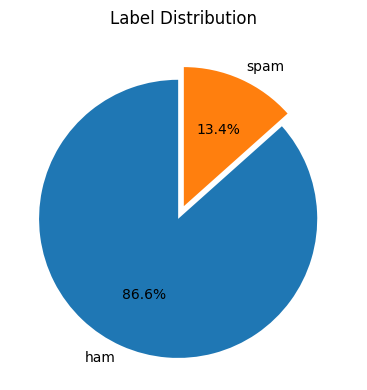

In [88]:
label_counts = df["label"].value_counts()
labels = label_counts.index.tolist()
sizes = label_counts.values

explode = [0.1] + [0] * (len(labels) - 1)

plt.figure(figsize=(6, 4))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, explode=explode)
plt.title("Label Distribution")
plt.tight_layout()
plt.show()

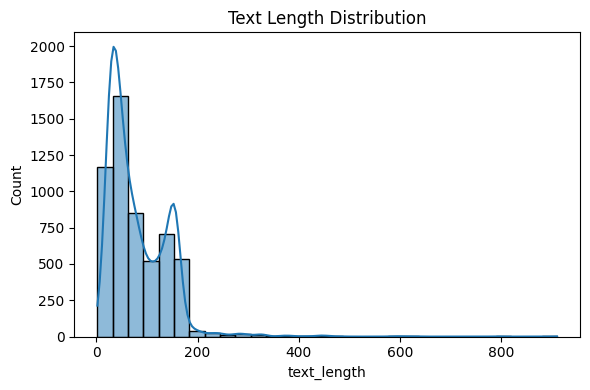

In [89]:
plt.figure(figsize=(6, 4))
sns.histplot(df["text_length"], bins=30, kde=True)
plt.title("Text Length Distribution")
plt.tight_layout()
plt.show()

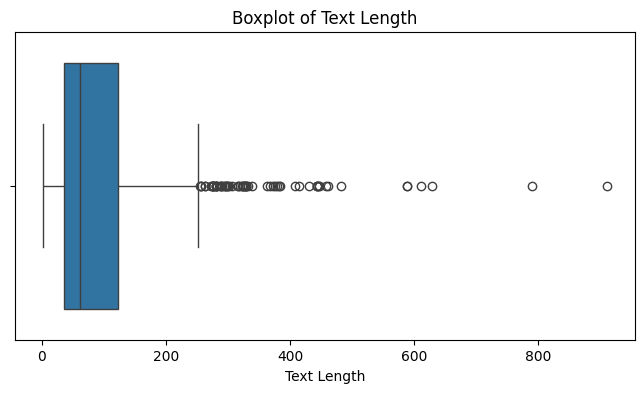

In [90]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["text_length"])
plt.title("Boxplot of Text Length")
plt.xlabel("Text Length")
plt.show()

## Этап 3 - Улучшим данные

**Выбросы**

In [91]:
Q1 = df["text_length"].quantile(0.25)
Q3 = df["text_length"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df["text_length"] >= lower_bound) & (df["text_length"] <= upper_bound)]
print("Original shape:", df.shape)
print("After removing outliers:", df_clean.shape)

Original shape: (5574, 3)
After removing outliers: (5507, 3)


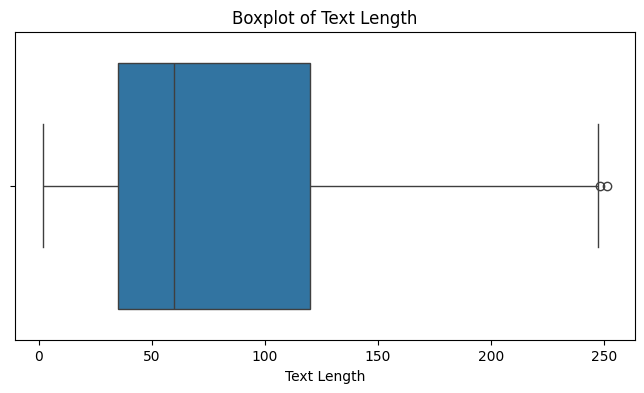

In [92]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["text_length"])
plt.title("Boxplot of Text Length")
plt.xlabel("Text Length")
plt.show()

**Аугментация**

In [93]:
class_counts = df_clean["label"].value_counts()
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
num_to_generate = class_counts[majority_class] - class_counts[minority_class]

print(
    f"Majority: {majority_class} ({class_counts[majority_class]}), "
    f"Minority: {minority_class} ({class_counts[minority_class]})"
)
print(f"Need to generate {num_to_generate} new samples for '{minority_class}'.")

Majority: ham (4760), Minority: spam (747)
Need to generate 4013 new samples for 'spam'.


In [94]:
augs = [naw.SynonymAug(aug_src="wordnet"), naw.RandomWordAug(action="swap"), naw.RandomWordAug(action="delete")]

In [95]:
minority_texts = df_clean[df_clean["label"] == minority_class]["text"].tolist()

new_samples = []
for _ in range(num_to_generate):
    orig_text = random.choice(minority_texts)
    aug = random.choice(augs)
    aug_text = aug.augment(orig_text)
    new_samples.append(
        {
            "label": minority_class,
            "text": orig_text,
            "clean_text": aug_text,
            "text_length": len(aug_text),
        }
    )

In [96]:
df_augmented = pd.DataFrame(new_samples)
df_balanced = pd.concat([df_clean, df_augmented], ignore_index=True)
df_balanced.shape

(9520, 4)

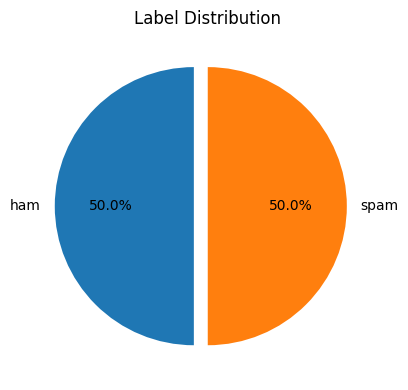

In [97]:
label_counts = df_balanced["label"].value_counts()
labels = label_counts.index.tolist()


sizes = label_counts.values


explode = [0.1] + [0] * (len(labels) - 1)


plt.figure(figsize=(6, 4))


plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, explode=explode)
plt.title("Label Distribution")
plt.tight_layout()
plt.show()

In [98]:
df_balanced.to_csv("../data/interim/spam.csv", sep=";", index=False)

## Этап 4 - Очистка данных

In [99]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [100]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words]
    return " ".join(tokens)


df_balanced["clean_text"] = df_balanced["text"].apply(clean_text)

In [101]:
df_balanced["target"] = df_balanced["label"].map({"ham": 0, "spam": 1})
df_balanced.head()

,label,text,text_length,clean_text,target
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...,0
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts st ...,1
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think go usf life around though,0


In [102]:
df_balanced.to_csv("../data/processed/spam.csv", sep=";", index=False)

## Этап 5 - Обучение моделей

In [103]:
vectorizers = {"bow": CountVectorizer(), "tfidf": TfidfVectorizer()}

param_grid_common = {"vectorizer__ngram_range": [(1, 1), (1, 2)]}

metrics: dict[str, dict[str, float]] = {}

### LR

In [104]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_param_grid = {"model__C": [0.1, 1, 10]}

In [ ]:
for vec_name, vectorizer in vectorizers.items():
    pipeline_lr = Pipeline([("vectorizer", vectorizer), ("model", lr_model)])
    grid = {**param_grid_common, **lr_param_grid}
    gs_lr = GridSearchCV(
        pipeline_lr,
        grid,
        cv=5,
        scoring=["accuracy", "f1", "roc_auc"],
        refit="roc_auc",
        n_jobs=-1,
        verbose=5,
    )
    gs_lr.fit(df_balanced["clean_text"], df_balanced["target"])

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [107]:
results = gs_lr.cv_results_
metrics["lr"] = {}
for metric in ["accuracy", "f1", "roc_auc"]:
    best_index = results[f"rank_test_{metric}"].argmin()
    best_score = results[f"mean_test_{metric}"][best_index]
    metrics["lr"][metric] = best_score
    print(f"Best {metric} score: {best_score:.4f}")

Best accuracy score: 0.9951
Best f1 score: 0.9951
Best roc_auc score: 0.9991


In [ ]:
best_lr = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(ngram_range=(1, 2))),
        ("model", LogisticRegression(C=10, max_iter=1000, random_state=42)),
    ]
)
best_lr.fit(df_balanced["clean_text"], df_balanced["target"])

In [119]:
with open("../models/lr.pkl", "wb") as f:
    pickle.dump(best_lr, f)

### NB

In [108]:
nb_model = MultinomialNB()
nb_param_grid = {"model__alpha": [0.5, 1.0, 1.5]}

In [109]:
for vec_name, vectorizer in vectorizers.items():
    pipeline_nb = Pipeline([("vectorizer", vectorizer), ("model", nb_model)])
    grid = {**param_grid_common, **nb_param_grid}
    gs_nb = GridSearchCV(
        pipeline_nb, grid, cv=5, scoring=["accuracy", "f1", "roc_auc"], refit="roc_auc", n_jobs=-1, verbose=5
    )
    gs_nb.fit(df_balanced["clean_text"], df_balanced["target"])

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [110]:
results = gs_nb.cv_results_
metrics["nb"] = {}
for metric in ["accuracy", "f1", "roc_auc"]:
    best_index = results[f"rank_test_{metric}"].argmin()
    best_score = results[f"mean_test_{metric}"][best_index]
    metrics["nb"][metric] = best_score
    print(f"Best {metric} score: {best_score:.4f}")

Best accuracy score: 0.9837
Best f1 score: 0.9840
Best roc_auc score: 0.9998


In [ ]:
best_nb = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(ngram_range=(1, 2))),
        ("model", MultinomialNB(alpha=0.5)),
    ]
)
best_nb.fit(df_balanced["clean_text"], df_balanced["target"])

In [120]:
with open("../models/nb.pkl", "wb") as f:
    pickle.dump(best_nb, f)

### GB

In [111]:
gb_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_param_grid = {"model__n_estimators": [32, 64], "model__learning_rate": [0.05, 0.1]}

In [112]:
for vec_name, vectorizer in vectorizers.items():
    pipeline_gb = Pipeline([("vectorizer", vectorizer), ("model", gb_model)])
    grid = {**param_grid_common, **gb_param_grid}
    gs_gb = GridSearchCV(
        pipeline_gb, grid, cv=5, scoring=["accuracy", "f1", "roc_auc"], refit="roc_auc", n_jobs=-1, verbose=5
    )
    gs_gb.fit(df_balanced["clean_text"], df_balanced["target"])

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [113]:
results = gs_gb.cv_results_
metrics["gb"] = {}
for metric in ["accuracy", "f1", "roc_auc"]:
    best_index = results[f"rank_test_{metric}"].argmin()
    best_score = results[f"mean_test_{metric}"][best_index]
    metrics["gb"][metric] = best_score
    print(f"Best {metric} score: {best_score:.4f}")

Best accuracy score: 0.9213
Best f1 score: 0.9186
Best roc_auc score: 0.9772


In [ ]:
best_gb = Pipeline(
    [
        ("vectorizer", TfidfVectorizer(ngram_range=(1, 2))),
        ("model", GradientBoostingClassifier(n_estimators=64, random_state=42)),
    ]
)
best_gb.fit(df_balanced["clean_text"], df_balanced["target"])

In [123]:
with open("../models/gb.pkl", "wb") as f:
    pickle.dump(best_gb, f)

## Этап 6 - Результаты

In [ ]:
df_quality = pd.DataFrame(metrics)
df_quality.index = ["Accuracy", "F1", "ROC_AUC"]

In [126]:
styled_df = df_quality.style.highlight_max(color='lightgreen', axis=1)
styled_df

,lr,nb,gb
Accuracy,0.995063,0.983718,0.921324
F1,0.995084,0.983970,0.918641
ROC_AUC,0.999127,0.999790,0.977159


### Выводы

- Думаю, что рационально будет ранжировать модели по F1, так как эта метрика ближе к пониманию бизнеса о классификации (чем ROC AUC), но точнее Accuracy.
- Забавно, что простейшая модель показывает на данной задаче лучшее качество, результаты консистентны и без аугментации.
- Таким образом, будем использовать в сервисе GB с наиболее низкой ценой, далее NB и LR.